In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
print('Строк и столбцов:', df.shape)
print('Пропусков по столбцам:')
print(df.isna().sum())

Строк и столбцов: (301355, 5)
Пропусков по столбцам:
Дата            0
Склад           0
Контрагент      0
Номенклатура    0
Количество      0
dtype: int64


Проверяем формат столбцов

In [4]:
df.dtypes

Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'], format='%Y-%m-%d')
print(df.dtypes)
print('Период данных:', df['Дата'].min().date(), '-', df['Дата'].max().date())

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object
Период данных: 2018-01-04 - 2018-08-31


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = (df.groupby('Дата', as_index=False)['Количество'].sum()
                .rename(columns={'Количество': 'Количество продаж'}))

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

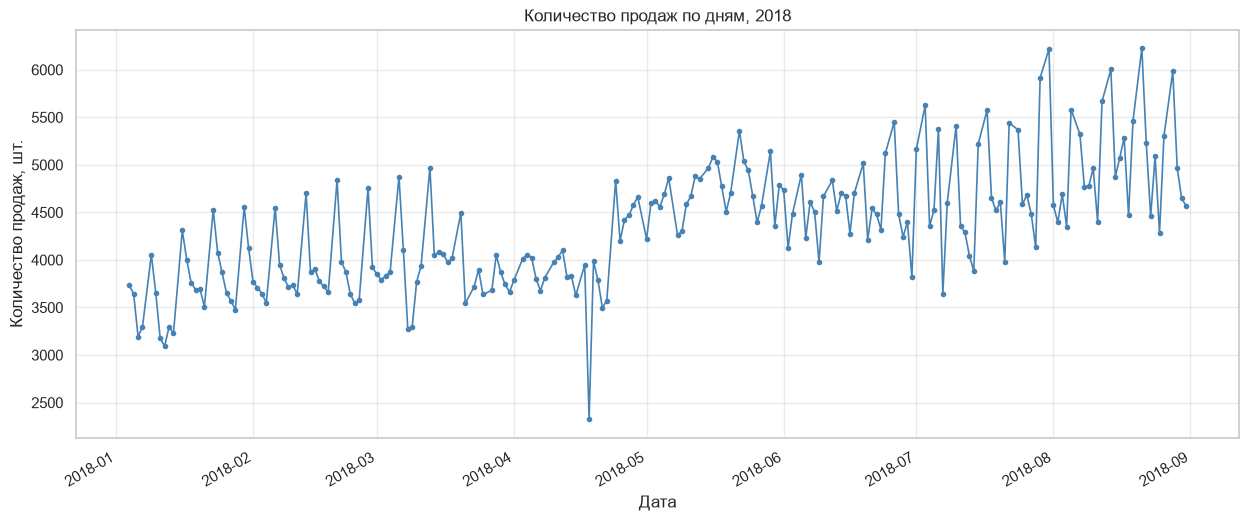

In [8]:
ax = grouped_df.plot(x='Дата', y='Количество продаж', figsize=(15, 6), color='steelblue',
                     linewidth=1.2, marker='o', markersize=3, legend=False)
ax.set_title('Количество продаж по дням, 2018')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество продаж, шт.')
ax.grid(True, which='both', alpha=0.4)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**Что видно на графике:**

1. **Период.** График охватывает январь-август 2018 года: продажи за каждый день с начала января до конца августа.
2. **Общий тренд - рост.** Продажи к концу периода заметно выше, чем в начале: в январе точки в основном в диапазоне примерно 3100-4500 шт., в августе - примерно 4300-6200 шт.
3. **Два разных периода.**
   - *Январь - середина апреля:* продажи колеблются примерно на одном уровне, в основном 3500-4100 шт., без явного роста.
   - *С конца апреля:* резкий подъём - за несколько дней уровень поднимается примерно до 4500-4800 шт. и дальше уже не возвращается к зимним значениям. После этого рост продолжается плавно: в мае-июне основная масса точек в районе 4300-5000 шт., в июле-августе примерно 4500-5500 шт.
4. **Регулярные пики.** В январе-марте хорошо видны повторяющиеся примерно раз в неделю резкие подъёмы до  4500-5000 шт. с последующим спадом. Это говорит о недельной цикличности продаж. Летом цикличность тоже есть, но она менее ровная
5. **Резкий провал в середине апреля.** Самая низкая точка графика - около 2300 шт., почти в два раза ниже соседних дней (примерно 3900-4000 шт). На следующий день продажи возвращаются к обычному уровню - это разовая аномалия, а не спад.
6. **Максимумы — в конце июля и в августе.** Самые высокие точки - около 6200 шт. (конец июля и вторая половина августа). В августе несколько дней превышают 5900-6000 шт.
7. **Летом разброс больше.** В июле-августе соседние дни могут отличаться на 1500-2000 шт. (примерно от  3700 до 6200 шт.), тогда как в январе-марте разница обычно не больше 1000-1500 шт.

**Вывод:** продажи растут, основной рост произошёл скачком в конце апреля; внутри каждого месяца есть регулярные недельные колебания, а к лету они становятся сильнее. Разовый провал в середине апреля стоит проверить отдельно - это может быть неполный рабочий день или ошибка учёта.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
# Строка с максимальным количеством продаж в исходной таблице
max_row = df.loc[df['Количество'].idxmax()]
print('Строка с максимальным количеством продаж')
print(max_row)

# Проверка, что это действительно выброс: z-оценка и граница по межквартильному размаху
mean, std = df['Количество'].mean(), df['Количество'].std()
q1, q3 = df['Количество'].quantile([0.25, 0.75])
print(f"\nСреднее: {mean:.2f}, медиана: {df['Количество'].median():.0f}, стандартное отклонение: {std:.2f}")
print(f"z-оценка строки: {(max_row['Количество'] - mean) / std:.1f}")
print(f"Граница выбросов по IQR: {q3 + 1.5 * (q3 - q1):.1f}")

df.nlargest(5, 'Количество')

Строка с максимальным количеством продаж
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Среднее: 2.95, медиана: 2, стандартное отклонение: 3.00
z-оценка строки: 65.7
Граница выбросов по IQR: 8.5


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200
260398,2018-07-31,4,address_125,product_1,140
260399,2018-07-31,4,address_125,product_2,100
258867,2018-07-29,4,address_142,product_1,80
258868,2018-07-29,4,address_142,product_2,70


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
summer_wed_wh3 = df[
    (df['Дата'].dt.dayofweek == 2)            # среда (понедельник = 0)
    & (df['Дата'].dt.month.isin([6, 7, 8]))   # июнь, июль, август
    & (df['Склад'] == 3)
]

top_products = (summer_wed_wh3.groupby('Номенклатура')['Количество'].sum()
                .sort_values(ascending=False))

print('\nТоповый товар по средам за июнь, июль, август у 3 склада:', top_products.idxmax(), '—', int(top_products.max()), 'шт.')


Топовый товар по средам за июнь, июль, август у 3 склада: product_1 — 2267 шт.


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [11]:
raw = pd.read_excel('Погода.xlsx', sheet_name='Лист2', header=None, dtype=str)
header_row = raw.index[raw[0] == 'Местное время в Астане'][0]      # ищем строку заголовков
weather_raw = raw.iloc[header_row + 1:].set_axis(raw.iloc[header_row], axis=1).reset_index(drop=True)
print('Наблюдений:', len(weather_raw), '| столбцов:', weather_raw.shape[1])

weather = weather_raw[['Местное время в Астане', 'T']].copy()
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], format='%d.%m.%Y %H:%M').dt.normalize()
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')     # в эксель значения сохранены как текст

# Средняя температура за день
weather_daily = weather.groupby('Дата')['T'].mean().round(1).reset_index()
print('Температура: дней', len(weather_daily), '|',
      weather_daily['Дата'].min().date(), '-', weather_daily['Дата'].max().date())
print('Наблюдений в сутки (обычно 8):', weather.groupby('Дата').size().describe()[['min', 'max']].to_dict())

# Объединяем с продажами: берем только те дни, когда были продажи
merged_df = grouped_df.merge(weather_daily, on='Дата', how='left')
print('Дней продаж без температуры:', merged_df['T'].isna().sum())
merged_df.head()

Наблюдений: 1918 | столбцов: 30
Температура: дней 240 | 2018-01-04 - 2018-08-31
Наблюдений в сутки (обычно 8): {'min': 6.0, 'max': 8.0}
Дней продаж без температуры: 0


,Дата,Количество продаж,T
0,2018-01-04,3734,-14.1
1,2018-01-05,3643,-16.9
2,2018-01-06,3193,-13.3
3,2018-01-07,3298,-12.8
4,2018-01-09,4055,-6.2


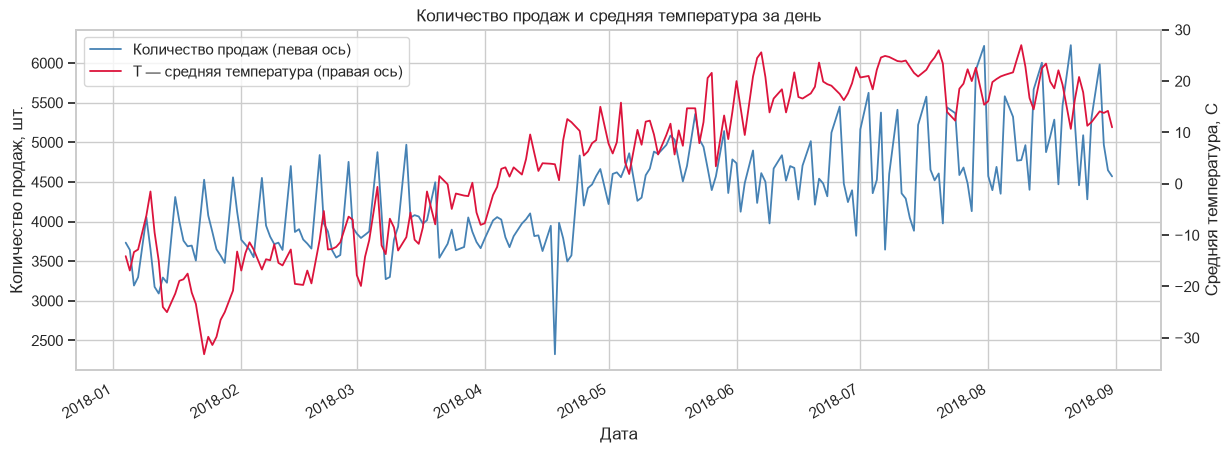

In [12]:
ax = merged_df.plot(x='Дата', y=['Количество продаж', 'T'], secondary_y='T',
                    color=['steelblue', 'crimson'], linewidth=1.3, figsize=(14, 5), mark_right=False)
ax.set_title('Количество продаж и средняя температура за день')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество продаж, шт.')
ax.right_ax.set_ylabel('Средняя температура, C')
lines = ax.get_lines() + ax.right_ax.get_lines()
ax.legend(lines, ['Количество продаж (левая ось)', 'T — средняя температура (правая ось)'], loc='upper left')
plt.show()

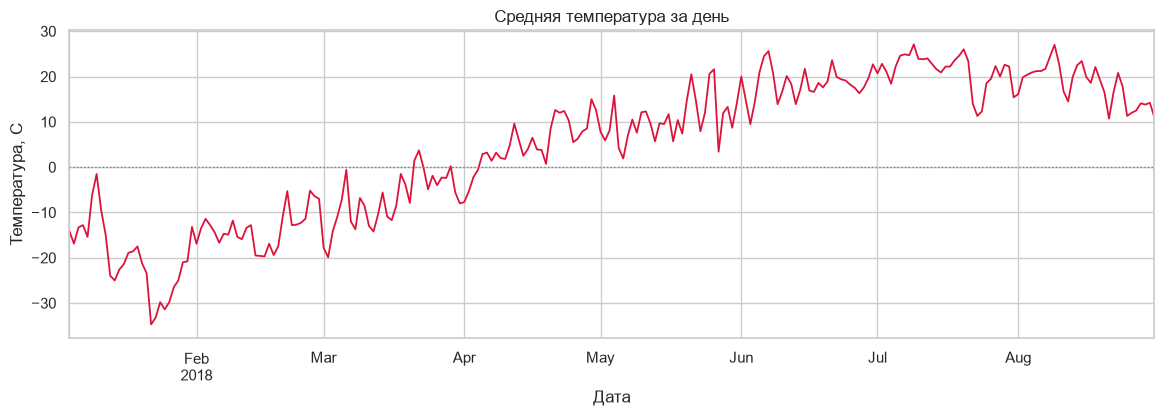

In [13]:
ax = weather_daily.plot(x='Дата', y='T', color='crimson', linewidth=1.3, legend=False, figsize=(14, 4))
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.set_title('Средняя температура за день')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, C')
plt.show()

**Что видно на графиках температуры:**

*График средней температуры*
1. **Зима - сильные морозы.** В январе-феврале температура в основном от -10 С до -20 C. Самые холодные дни - в конце января, около -35 C.
2. **Переход через ноль - в конце марта - начале апреля.** В апреле температура держится около 0-10 C.
3. **Весной - быстрое потепление с резкими скачками.** В мае-июне температура растёт примерно от +5 до +25 C, но с заметными похолоданиями: отдельные дни опускаются до +3-5 C.
4. **Лето — самый тёплый период.** В июле температура в основном около +18-27 C, в конце месяца - короткое похолодание до +11 C. В августе около +15-25C, к концу месяца заметно холоднее - до +11-14 C.

*Общий график продаж и температуры*

5. **Общее направление совпадает.** Обе линии идут вверх от зимы к лету: продажи с  3500-4000 до 4500-6000 шт., температура - от −35С до +25C.
6. **Скачок продаж в конце апреля совпадает с потеплением.** Примерно в эти же дни температура уверенно уходит выше +10C.
7. **День в день продажи за температурой не следуют.**
   - Сильное похолодание в конце января (до −35 C) на продажах не видно: они остаются в обычном январском диапазоне в районе 3500-4500 шт. и сохраняют свои недельные колебания.
   - Летом температура держится в основном около +15-25 C, а продажи продолжают расти и сильно колеблются от дня к дню, независимо от температурных колебаний.
   - В конце августа температура заметно снижается, а продажи остаются высокими.

**Вывод:** по графикам видна общая сезонная связь - летом и теплее и продаж больше, а рост продаж в конце апреля пришёлся на период потепления. Но прямой зависимости продаж от погоды конкретного дня на графике не видно: резкие изменения температуры не отражаются на продажах. Утверждать что продажи растут именно из-за температуры по этим графикам нельзя.